# Graph structures

A unique feature to Graph Neural Networks is that these models learn by the enforcement of a spatial structure; a graph. When applied to epidemiological problems, GNNs should have access to meaningful graph structures which encode the (spatial) relations between the different entities modelled. A graph consists of **nodes** (entities) connected by **edges** (representing relationships between them). Edges may be weighted to quantify connection strength. In epidemiological applications, nodes may represent geographic regions such as districts or municipalities, while edges encode relationships relevant to disease transmission—including travel patterns or spatial proximity. In this project, a graph structure $\mathcal{G} = (\mathcal{V}, \mathcal{E})$ represents Germany, with $N = |\mathcal{V}|$ nodes representing the districts and edges $\mathcal{E}$ encoding various forms of spatial connectivity. GNNs employ message-passing mechanisms that enable each node to aggregate information from its connected neighbors, effectively capturing the relational dynamics within the network. This ability to integrate diverse types of information across graph structures makes GNNs particularly promising for epidemiological modeling (Kraemer, 2025)


### Graph Structures used
In this project, multiple graph construction strategies are explored, to capture different aspects of spatial connectivity. Per administrative unit in Germany, albeit *NUTS1*, *NUTS2* or *NUTS3*, we model epidemiological timeseries, representing incidence rates on casenumbers of the respective infectious disease. The following classes of graph structures are studied:

- **Identity graph**:  A baseline graph structure in which each node is only connected to itself. Therefore, for the prediction of the next state of node $i$, only information of its own past state is used.
- **Mesh graph**: A baseline graph structure in which each node is connected to all other nodes by equal weight.
- **Boolean Neighbors**: A graph representing geographical information by connecting every node to the nodes it shares a geographic border with.
- **Gravity-model**: Graphs encoding geographical and socio-demographic information based on the gravity model of spatial interaction. For any pair of nodes $i, j$, edge weights are computed analogously to the gravitational force between two objects. The connection strength is a function of the population size of $i, j$, and the inverse of their distance. Two variations are used, one with $k=3$ (gravity1) and one with $k=7$ (gravity2).
- **Commuter-based**: Graphs representing commuting data made available by the Bundesagentur für Arbeit \cite{Arbeitsagentur}. Two variations are used based on the commuting data for 2024, one with $k=3$ (commuter 1) and one in which each node's connections are kept, so long as there are more than 1 000 daily commuters between them (commuter2).

 In addition, a threshold of $k$ connections per node may be implemented, emphasizing strong connections over many connections.


In [1]:
from src.utils import get_data_env
from src.dataloading import EpiConfig, DataOrchestrator
from src.graphconstruction import StaticGraphOrchestrator, DynamicGraphOrchestrator

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False

horizon_size    = 1
horizon_leadtime= 3
sequence_length = 1
lag_num         = 1

config = EpiConfig(
    disease             = 'influenza',
    data_env_dir        = get_data_env(),
    date_range          = (min_date, max_date),
    horizon_size        = horizon_size,
    sequence_length     = sequence_length,
    horizon_leadtime    = horizon_leadtime,
    lag_num             = lag_num,
    nuts_level          = nuts_level,
    log_transform       = ['incidence'],
    split_berlin        = False,
    include_population  = False,
    split_trainval      = split_trainval, 
    split_valtest       = split_valtest,
    target_column       = 'cases',
    lag_column          = 'incidence',  
    verbose             = 0
    )    
data_orchestrator = DataOrchestrator(config).build()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: /local/job_23264135/wissdaten/ZKI-PH4/deschrijvers_wissdaten/data/processed/germany/geospatial/shapefiles/shape_nuts3.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [8]:
static_graphconstruction = StaticGraphOrchestrator(data_orchestrator)

# identity graph
static_graphconstruction.generate_graphstructure(method = 'identity', graphname='identity_graph')

# mesh graph
static_graphconstruction.generate_graphstructure(method = 'mesh', graphname='mesh_graph')

# Neighbors
#   boolean-self
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection='mean', graphname = 'geographical_neighbors1')
#   boolean-nonself
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection='0', graphname = 'geographical_neighbors2')
#   numerical-self
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection = 'mean', normalization='rowwise', graphname = 'geographical_neighbors3')
#   numerical-nonself
static_graphconstruction.generate_graphstructure(method='geographic_neighbors', self_connection='0', normalization='rowwise', graphname = 'geographical_neighbors4')

#   sparse - long distance gravity model
static_graphconstruction.generate_graphstructure(method             = 'gravity_model', 
                                                 self_connection    = '0',
                                                 max_distance       = 1000_000,
                                                 top_k              = 3,
                                                 alpha              = 1,
                                                 decay              = 1,
                                                 normalization     = 'rowwise',
                                                 graphname = 'gravity1'
                                                 )
#   dense - long distance gravity model
static_graphconstruction.generate_graphstructure(method             = 'gravity_model', 
                                          self_connection    = '0',
                                          max_distance       = 1000_000,
                                          top_k              = 10,
                                          alpha              = 1,
                                          decay              = 1,
                                          normalization     = 'rowwise',
                                          graphname = 'gravity2'
                                          )
#   sparse - short distance gravity model
static_graphconstruction.generate_graphstructure(method             = 'gravity_model', 
                                          self_connection    = '0',
                                          max_distance       = 1000_000,
                                          top_k              = 3,
                                          alpha              = 2,
                                          decay              = 1,
                                          normalization     = 'rowwise',
                                          graphname = 'gravity3'
                                          )
#   dense - short distance gravity model
static_graphconstruction.generate_graphstructure(method             = 'gravity_model', 
                                          self_connection    = '0',
                                          max_distance       = 1000_000,
                                          top_k              = 10,
                                          alpha              = 2,
                                          decay              = 1,
                                          normalization     = 'rowwise',
                                          graphname = 'gravity4'
                                          )
#   medium-dense - medium-distance gravity model
static_graphconstruction.generate_graphstructure(method             = 'gravity_model', 
                                          self_connection    = '0',
                                          max_distance       = 1000_000,
                                          top_k              = 7,
                                          alpha              = 1.5,
                                          decay              = 1,
                                          normalization     = 'rowwise',
                                          graphname = 'gravity5'
                                          )

# Commuter
#   static - 2024-1
#   low threshold
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 500,
    normalization      = 'rowwise',
    graphname           = 'static_commuter24_1',
    year                = '2024'
)
#   static - 2024-2
#   medium threshold
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 1000,
    normalization      = 'rowwise',
    graphname           = 'static_commuter24_2',
    year                = '2024'
)
#   static - 2024-3
#   high threshold
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 2500,
    normalization      = 'rowwise',
    graphname           = 'static_commuter24_3',
    year                = '2024'
)
#   static - 2024-4
#   top_k=4
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 0,
    normalization      = 'rowwise',
    graphname           = 'static_commuter24_4',
    year                = '2024',
    top_k               = 4
)

# Commuter
#   static - 2014-1
#   low threshold
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 500,
    normalization      = 'rowwise',
    graphname           = 'static_commuter14_1',
    year                = '2014'
)
#   static - 2014-2
#   medium threshold
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 1000,
    normalization      = 'rowwise',
    graphname           = 'static_commuter14_2',
    year                = '2014'
)
#   static - 2014-3
#   high threshold
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 2500,
    normalization      = 'rowwise',
    graphname           = 'static_commuter14_3',
    year                = '2014'
)
#   static - 2014-4
#   top_k=4
static_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    self_connection     = 'eps',
    commuting_threshold = 0,
    normalization      = 'rowwise',
    graphname           = 'static_commuter14_4',
    year                = '2014',
    top_k               = 4
)

# static_graphconstruction.graph_registry.save_graphentry('ALL')

normalization method is None
    ✓ Graph registered  : identity_graph successfully registered
normalization method is None
    ✓ Graph registered  : mesh_graph successfully registered
normalization method is None
    ✓ Graph registered  : geographical_neighbors1 successfully registered
normalization method is None
    ✓ Graph registered  : geographical_neighbors2 successfully registered
    ✓ Graph registered  : geographical_neighbors3 successfully registered
    ✓ Graph registered  : geographical_neighbors4 successfully registered
    ✓ Graph registered  : gravity1 successfully registered
    ✓ Graph registered  : gravity2 successfully registered
    ✓ Graph registered  : gravity3 successfully registered
    ✓ Graph registered  : gravity4 successfully registered
    ✓ Graph registered  : gravity5 successfully registered
✓ commuting-data loaded for ['2024']
    ✓ Graph registered  : static_commuter24_1 successfully registered
✓ commuting-data loaded for ['2024']
    ✓ Graph registered 

In [2]:
dynamic_graphconstruction = DynamicGraphOrchestrator(data_orchestrator)

# dynamic_graphconstruction.generate_graphstructure(method = 'gravity_model', time_window=['2001-01-01','2025-01-01'], frequency = 'yearly', graphname='dynamic_gravity', normalization='rowwise')

# Dynamic gravity graphs
# number 1: sparse - long distance gravity model
dynamic_graphconstruction.generate_graphstructure(
    method              = 'gravity_model', 
    time_window         = ['2005-01-01','2024-01-01'],
    frequency           = 'yearly',    
    self_connection     = '0',
    max_distance        = 1000_000,
    top_k               = 3,
    alpha               = 1,
    decay               = 1,
    normalization       = 'rowwise',
    graphname           = 'dynamic_gravity1'
)

# number 2: dense - long distance gravity model
dynamic_graphconstruction.generate_graphstructure(
    method              = 'gravity_model', 
    time_window         = ['2005-01-01','2024-01-01'],
    frequency           = 'yearly',    
    self_connection     = '0',
    max_distance        = 1000_000,
    top_k               = 10,
    alpha               = 1,
    decay               = 1,
    normalization       = 'rowwise',
    graphname           = 'dynamic_gravity2'
)

# number 3: sparse - short distance gravity model
dynamic_graphconstruction.generate_graphstructure(
    method              = 'gravity_model', 
    time_window         = ['2005-01-01','2024-01-01'],
    frequency           = 'yearly',    
    self_connection     = '0',
    max_distance        = 1000_000,
    top_k               = 3,
    alpha               = 2,
    decay               = 1,
    normalization       = 'rowwise',
    graphname           = 'dynamic_gravity3'
)

# number 4: dense - short distance gravity model
dynamic_graphconstruction.generate_graphstructure(
    method              = 'gravity_model', 
    time_window         = ['2005-01-01','2024-01-01'],
    frequency           = 'yearly',    
    self_connection     = '0',
    max_distance        = 1000_000,
    top_k               = 10,
    alpha               = 2,
    decay               = 1,
    normalization       = 'rowwise',
    graphname           = 'dynamic_gravity4'
)

# number 5: medium-dense - medium-distance gravity model
dynamic_graphconstruction.generate_graphstructure(
    method              = 'gravity_model', 
    time_window         = ['2005-01-01','2024-01-01'],
    frequency           = 'yearly',    
    self_connection     = '0',
    max_distance        = 1000_000,
    top_k               = 7,
    alpha               = 1.5,
    decay               = 1,
    normalization       = 'rowwise',
    graphname           = 'dynamic_gravity5'
)

# Dynamic commuter graphs
#   number 1: low threshold
dynamic_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    time_window         = ['2002-01-01','2024-01-01'],
    frequency           = 'yearly',    
    self_connection     = 'eps',
    commuting_threshold = 500,
    normalization       = 'rowwise',
    graphname           = 'dynamic_commuter1'
)
#   number 2: medium threshold
dynamic_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    time_window         = ['2002-01-01','2024-01-01'],  
    frequency           = 'yearly',      
    self_connection     = 'eps',
    commuting_threshold = 1000,
    normalization       = 'rowwise',
    graphname           = 'dynamic_commuter2'
)
#   number 3: high threshold
dynamic_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    time_window         = ['2002-01-01','2024-01-01'],    
    frequency           = 'yearly',    
    self_connection     = 'eps',
    commuting_threshold = 2500,
    normalization       = 'rowwise',
    graphname           = 'dynamic_commuter3'
)
#   number 4: top-k
dynamic_graphconstruction.generate_graphstructure(
    method              = 'commuter', 
    time_window         = ['2002-01-01','2024-01-01'],    
    frequency           = 'yearly',    
    self_connection     = 'eps',
    commuting_threshold = 0,
    normalization       = 'rowwise',
    graphname           = 'dynamic_commuter4',
    top_k               = 4
)
# dynamic_graphconstruction.graph_registry.save_graphentry('ALL')

generating graph => dynamic_gravity1: 100%|███████████████████████████████████████████████████| 20/20 [00:07<00:00,  2.61it/s]


    ✓ Graph registered  : dynamic_gravity1 successfully registered


generating graph => dynamic_gravity2: 100%|███████████████████████████████████████████████████| 20/20 [00:08<00:00,  2.40it/s]


    ✓ Graph registered  : dynamic_gravity2 successfully registered


generating graph => dynamic_gravity3: 100%|███████████████████████████████████████████████████| 20/20 [00:07<00:00,  2.62it/s]


...

    ✓ Graph registered  : dynamic_commuter2 successfully registered
✓ commuting-data loaded for ['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


generating graph => dynamic_commuter3: 100%|██████████████████████████████████████████████████| 23/23 [00:00<00:00, 25.97it/s]


    ✓ Graph registered  : dynamic_commuter3 successfully registered
✓ commuting-data loaded for ['2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024']


generating graph => dynamic_commuter4: 100%|██████████████████████████████████████████████████| 23/23 [00:01<00:00, 12.94it/s]

    ✓ Graph registered  : dynamic_commuter4 successfully registered


In [3]:
from tqdm import tqdm

fs = []

for idx in tqdm(range(23)):
    fs.append(dynamic_graphconstruction.preview_graphstructure('dynamic_commuter1',time_idx=idx, node_idx=26,subplots=False))

  0%|                                                                                                  | 0/23 [00:00<?, ?it/s]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/graphconstruction/staticgraphviewer.py:241: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df.geometry.centroid
  4%|███▉                                                                                      | 1/23 [00:01<00:42,  1.95s/it]/scratch/de-schrijvers/projects/infectious_disease_gnn/src/graphconstruction/staticgraphviewer.py:241: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df.geometry.centroid
  9%|███████▊                                                                                  | 2/23 

In [ ]:
dynamic_graphconstruction.graph_registry.get_entry('dynamic_gravity5')

GraphEntry(structure=<DynamicGraphStructure(T=20, 2005 to 2024)>, summary=Dynamic Graph Statistics:
  Time range: 2005 to 2024
  Snapshots: 20
  Nodes (constant): 400
  Edges: 2800 - 2800 (min-max)
  Edge Density: 0.0175 - 0.0175
  Edge Weight Mean: 0.1429 - 0.1429, config=DynamicGraphConfig(method='gravity_model', time_window=[2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024], frequency='yearly', self_connection='0', normalization='rowwise', kwargs={'max_distance': 1000000, 'top_k': 7, 'alpha': 1.5, 'decay': 1}), mode='dynamic')

In [9]:
static_graphconstruction

<StaticGraphOrchestrator(level nuts3. Registry: <GraphRegistry(N = 19 graphs:
	identity_graph, mesh_graph, geographical_neighbors1, geographical_neighbors2, geographical_neighbors3, geographical_neighbors4, gravity1, gravity2, gravity3, gravity4, gravity5, static_commuter24_1, static_commuter24_2, static_commuter24_3, static_commuter24_4, static_commuter14_1, static_commuter14_2, static_commuter14_3, static_commuter14_4))>

In [27]:
from src.plotting import ManagedFigure, ManagedFigureGrid
preview_id_graph = ManagedFigure(static_graphconstruction.preview_graphstructure('identity_graph',node_idx = 26,subplots = False))
preview_gn_graph = ManagedFigure(static_graphconstruction.preview_graphstructure('geographical_neighbors1',node_idx = 26,subplots = False))
preview_gr_graph = ManagedFigure(static_graphconstruction.preview_graphstructure('gravity1',node_idx = 26,subplots = False))
preview_cm_graph = ManagedFigure(static_graphconstruction.preview_graphstructure('static_commuter24_1',node_idx = 26,subplots = False))

/scratch/de-schrijvers/projects/infectious_disease_gnn/src/graphconstruction/staticgraphviewer.py:241: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df.geometry.centroid
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/graphconstruction/staticgraphviewer.py:241: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df.geometry.centroid
/scratch/de-schrijvers/projects/infectious_disease_gnn/src/graphconstruction/staticgraphviewer.py:241: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  centroids = df.geometry.centroid
/scratch/de-schrijvers/projects

In [32]:
preview_id_graph.labels.change_suptitle('Graphstructure identity graph', fontweight = 'bold', fontsize = 12).labels.set_suptitle_y(y=1.03).labels.change_title('Neighborhood of Hannover')
preview_gn_graph.labels.change_suptitle('Graphstructure geographical neighbors - graph', fontweight = 'bold', fontsize = 12).labels.set_suptitle_y(y=1.03).labels.change_title('Neighborhood of Hannover')
preview_gr_graph.labels.change_suptitle('Graphstructure gravity model - graph', fontweight = 'bold', fontsize = 12).labels.set_suptitle_y(y=1.03).labels.change_title('Neighborhood of Hannover')
preview_cm_graph.labels.change_suptitle('Graphstructure commuter model - graph', fontweight = 'bold', fontsize = 12).labels.set_suptitle_y(y=1.03).labels.change_title('Neighborhood of Hannover')


<Fig(n_axes = 1, legend, ticks, labels)>

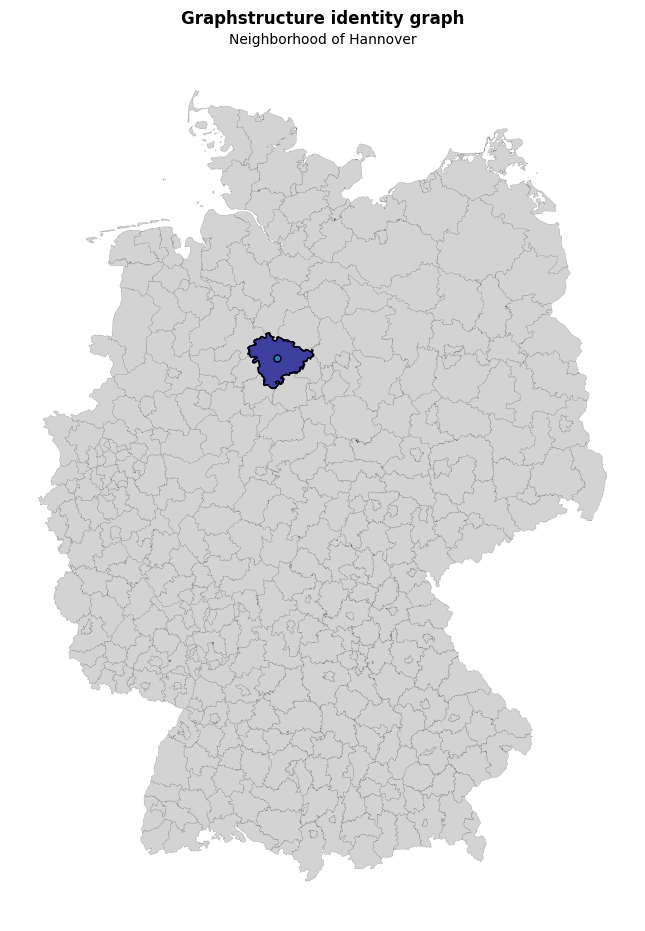

In [33]:
preview_id_graph.show()